# Cyber Security Attack EDA

This dataset contains 100,000 synthetic network traffic records generated for machine learning applications in cybersecurity. The dataset simulates common network behaviors and attack patterns including DDoS attacks, brute-force login attempts, and port scanning activities.

Data Source: https://www.kaggle.com/datasets/juanschafle/cyber-attack-detection-using-network-traffic

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("juanschafle/cyber-attack-detection-using-network-traffic")

print("Path to dataset files:", path)
available_files = sorted(os.listdir(path))
available_files

Path to dataset files: C:\Users\FATHIR\.cache\kagglehub\datasets\juanschafle\cyber-attack-detection-using-network-traffic\versions\1


['cyber_attack_dataset_100000.csv']

In [4]:
df = pd.read_csv(os.path.join(path, 'cyber_attack_dataset_100000.csv'))

## Chapter 1 : Data Overview

In [5]:
df

,duration,src_bytes,dst_bytes,packet_count,protocol,failed_logins,attack_type
0,1,8605,418,631,TCP,0,DDoS
1,1,499,148,131,UDP,0,PortScan
2,10,370,160,105,UDP,0,PortScan
3,2,5138,320,666,TCP,0,DDoS
4,36,524,467,58,UDP,10,BruteForce
...,...,...,...,...,...,...,...
99995,10,380,41,143,TCP,0,PortScan
99996,2,153,146,85,TCP,0,PortScan
99997,37,161,114,61,UDP,10,BruteForce
99998,4,142,69,73,TCP,0,PortScan


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   duration       100000 non-null  int64
 1   src_bytes      100000 non-null  int64
 2   dst_bytes      100000 non-null  int64
 3   packet_count   100000 non-null  int64
 4   protocol       100000 non-null  str  
 5   failed_logins  100000 non-null  int64
 6   attack_type    100000 non-null  str  
dtypes: int64(5), str(2)
memory usage: 6.3 MB


In [7]:
print("\t", "="*15, "DATA OVERVIEW", "="*15)

overview = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Features",
        "Dataset Size (MB)",

        "Unique Protocols",
        "Unique Attack Types",

        "Most Common Protocol",
        "Most Common Attack Type",

        "Missing Values",
        "Duplicate Records",

        "Average Duration",
        "Median Duration",
        "Maximum Duration",
        "Minimum Duration",

        "Average Source Bytes",
        "Median Source Bytes",
        "Maximum Source Bytes",
        "Minimum Source Bytes",

        "Average Destination Bytes",
        "Median Destination Bytes",
        "Maximum Destination Bytes",
        "Minimum Destination Bytes",

        "Average Packet Count",
        "Median Packet Count",

        "Total Failed Logins"
    ],

    "Value": [
        len(df),
        len(df.columns),
        round(df.memory_usage(deep=True).sum() / 1024**2, 2),

        df["protocol"].nunique(),
        df["attack_type"].nunique(),

        df["protocol"].mode()[0],
        df["attack_type"].mode()[0],

        df.isnull().sum().sum(),
        df.duplicated().sum(),

        round(df["duration"].mean(), 2),
        df["duration"].median(),
        df["duration"].max(),
        df["duration"].min(),

        round(df["src_bytes"].mean(), 2),
        df["src_bytes"].median(),
        df["src_bytes"].max(),
        df["src_bytes"].min(),

        round(df["dst_bytes"].mean(), 2),
        df["dst_bytes"].median(),
        df["dst_bytes"].max(),
        df["dst_bytes"].min(),

        round(df["packet_count"].mean(), 2),
        df["packet_count"].median(),

        df["failed_logins"].sum()
    ]
})

overview

	 =============== DATA OVERVIEW ===============


,Metric,Value
0,Total Records,100000
1,Total Features,7
2,Dataset Size (MB),6.29
3,Unique Protocols,2
4,Unique Attack Types,4
5,Most Common Protocol,TCP
6,Most Common Attack Type,DDoS
7,Missing Values,0
8,Duplicate Records,1
9,Average Duration,16.46


## Chapter 2 : Data Quality Check

In [8]:
missing_summary = (
    df.isna()
      .sum()
      .reset_index(name='missing_count')
      .rename(columns={'index': 'column'})
)

missing_summary['missing_pct'] = (
    missing_summary['missing_count'] / len(df) * 100
)

missing_summary = missing_summary.sort_values(
    'missing_pct',
    ascending=False
)

missing_summary

,column,missing_count,missing_pct
0,duration,0,0.0
1,src_bytes,0,0.0
2,dst_bytes,0,0.0
3,packet_count,0,0.0
4,protocol,0,0.0
5,failed_logins,0,0.0
6,attack_type,0,0.0


In [9]:
numerical_cols = [
    'duration',
    'src_bytes',
    'dst_bytes',
    'packet_count',
    'failed_logins'
]

outlier_summary = []

for col in numerical_cols :
    series = df[col].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (series < lower_bound) |
        (series > upper_bound)
    ).sum()

    outlier_summary.append({
        'column': col,
        'count' : len(series),
        'mean' : round(series.mean(), 2),
        'median' : round(series.median(), 2),
        'min' : round(series.min(), 2),
        'max' : round(series.max(), 2),
        'iqr_lower_bound': round(lower_bound, 2),
        'iqr_upper_bound' : round(upper_bound, 2),
        'outlier_count' : outlier_count,
        'outlier_pct' : round(outlier_count/len(series) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    'outlier_pct',
    ascending=False
)

,column,count,mean,median,min,max,iqr_lower_bound,iqr_upper_bound,outlier_count,outlier_pct
2,dst_bytes,100000,426.17,256.0,20,2000,-359.5,948.5,13746,13.75
3,packet_count,100000,202.55,87.0,5,1000,-293.0,587.0,11556,11.56
1,src_bytes,100000,2219.63,781.0,50,10000,-3683.5,7048.5,10547,10.55
4,failed_logins,100000,1.63,0.0,0,10,-4.5,7.5,9446,9.45
0,duration,100000,16.46,10.0,1,60,-32.0,64.0,0,0.00


In [ ]:
summary = df.groupby('attack_type').agg(
    duration=('duration', 'mean'),
    src_bytes=('src_bytes', 'mean'),
    packet_count=('packet_count', 'mean'),
    failed_logins=('failed_logins', 'mean')
).reset_index()

summary['Average duration'] = summary.apply(
    lambda r: f"{r['duration']:.2f} seconds" + 
              (" (Long)" if r['attack_type'] == 'Normal' else 
               " (Very Short)" if r['attack_type'] == 'DDoS' else ""), 
    axis=1
)

summary['Average src_bytes'] = summary.apply(
    lambda r: f"{r['src_bytes']:,.0f} bytes" + 
              (" (Very Large)" if r['attack_type'] == 'DDoS' else ""), 
    axis=1
)

summary['Average packet_count'] = summary.apply(
    lambda r: f"{r['packet_count']:.1f} packets" + 
              (" (Very High)" if r['attack_type'] == 'DDoS' else ""), 
    axis=1
)

summary['Average failed_logins'] = summary.apply(
    lambda r: f"{r['failed_logins']:.2f}" + 
              (" times (Very High)" if r['attack_type'] == 'BruteForce' else ""), 
    axis=1
)

def get_dominant_protocol(group):
    counts = group['protocol'].value_counts()
    pct = (counts.max() / counts.sum()) * 100
    if pct > 99.9:
        return f"100% {counts.idxmax()}"
    else:
        return "Balanced (TCP & UDP)"

protocol_summary = df.groupby('attack_type').apply(get_dominant_protocol).reset_index(name='Dominant Protocol')

final_table = pd.merge(summary, protocol_summary, on='attack_type')

final_table = final_table[[
    'attack_type', 
    'Average duration', 
    'Average src_bytes', 
    'Average packet_count', 
    'Average failed_logins', 
    'Dominant Protocol'
]].rename(columns={'attack_type': 'Traffic Type (attack_type)'})

final_table


,Traffic Type (attack_type),Average duration,Average src_bytes,Average packet_count,Average failed_logins,Dominant Protocol
0,BruteForce,25.04 seconds,548 bytes,55.0 packets,6.51 times (Very High),100% UDP
1,DDoS,3.01 seconds (Very Short),"6,497 bytes (Very Large)",551.6 packets (Very High),0.00,100% TCP
2,Normal,32.42 seconds (Long),"1,545 bytes",27.5 packets,0.00,Balanced (TCP & UDP)
3,PortScan,5.49 seconds,275 bytes,174.4 packets,0.00,Balanced (TCP & UDP)


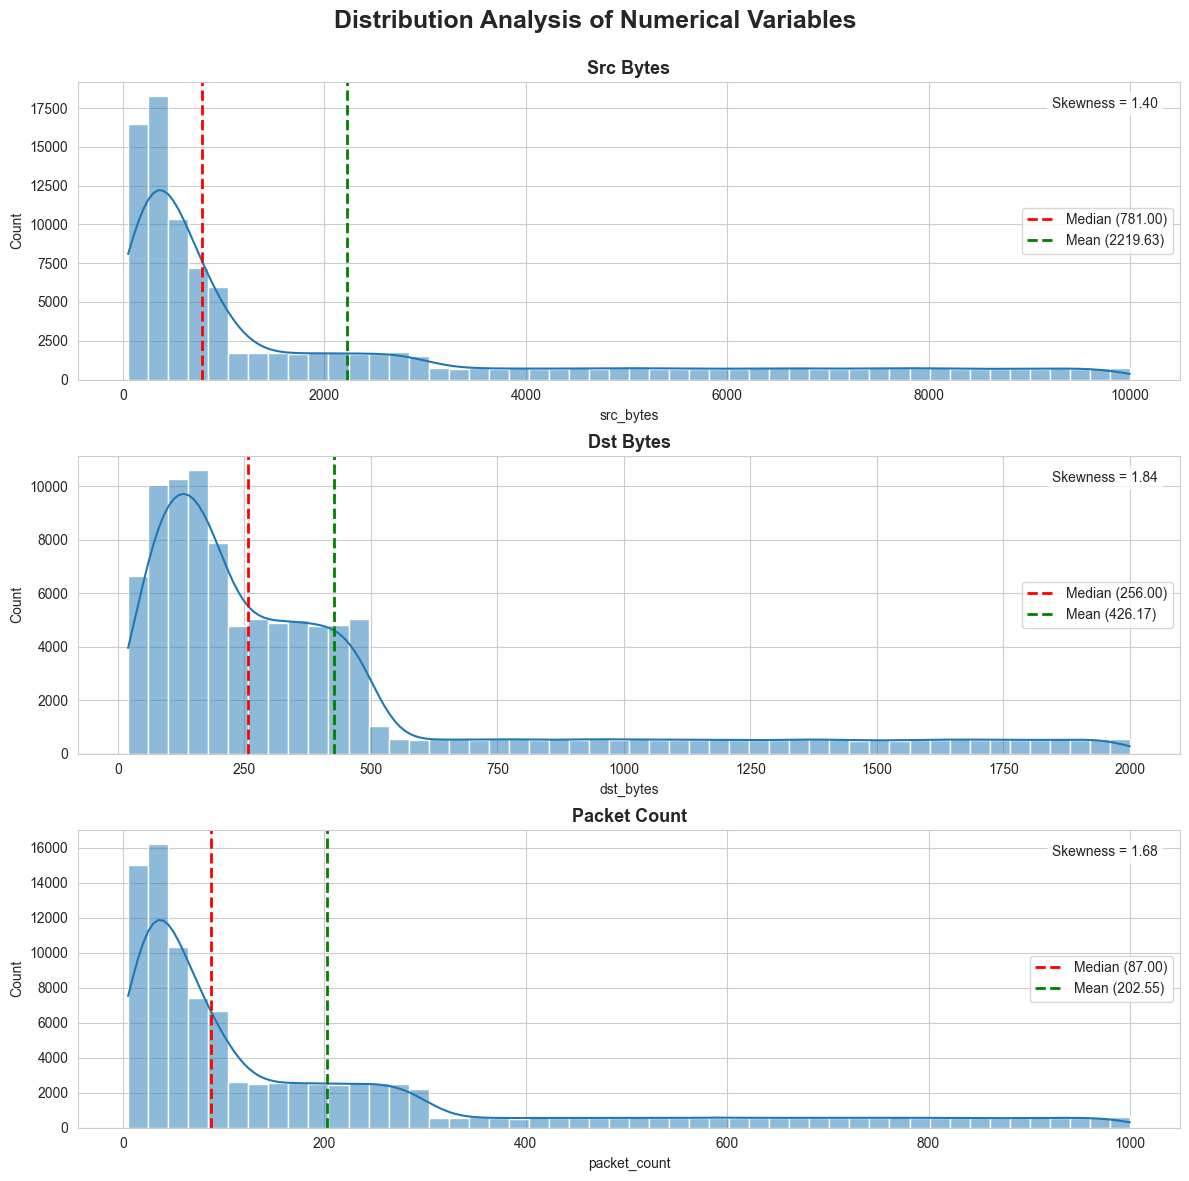

In [10]:
from scipy.stats import skew
import os

target_columns = [
    'src_bytes',
    'dst_bytes',
    'packet_count'
]

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 12)
)

axes = axes.flatten()

for ax, col in zip(axes, target_columns):

    mean_val = df[col].mean()
    median_val = df[col].median()
    skew_val = skew(df[col])

    sns.histplot(
        data=df,
        x=col,
        bins=50,
        kde=True,
        ax=ax
    )

    ax.axvline(
        median_val,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Median ({median_val:.2f})'
    )

    ax.axvline(
        mean_val,
        color='green',
        linestyle='--',
        linewidth=2,
        label=f'Mean ({mean_val:.2f})'
    )

    ax.set_title(
        f'{col.replace("_", " ").title()}',
        fontsize=13,
        fontweight='bold'
    )

    ax.set_xlabel(col)
    ax.set_ylabel('Count')

    ax.text(
        0.98,
        0.95,
        f'Skewness = {skew_val:.2f}',
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=10,
        bbox=dict(
            boxstyle='round',
            facecolor='white',
            alpha=0.8
        )
    )

    ax.legend()

plt.tight_layout()

fig.suptitle(
    'Distribution Analysis of Numerical Variables',
    fontsize=18,
    fontweight='bold'
)

fig.subplots_adjust(top=0.92)

os.makedirs('img', exist_ok=True)

filepath = os.path.join(
    'img',
    'Distribution Analysis of Numerical Variables.png'
)

plt.savefig(
    filepath,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

### Insight

- numeric variables (`src_bytes`, `dst_bytes`, and `packet_count`) show a similar distribution pattern, namely **positively skewed (right-skewed)** with a mean value that is consistently higher than the median.
- This indicates that most of the connections in the dataset have relatively low to moderate network activity, while there are a small number of connections with very high values ​​that form the long tail of the distribution.
- A skewness value in the range of 1.40–1.84 indicates that the data distribution is asymmetric and tends to be dominated by small-value observations. A significant difference between the mean and median indicates a connection with a significantly higher data transfer volume or number of packets than the majority of other connections.
- This pattern indicates that the network traffic characteristics in the dataset are heterogeneous and likely comprise several distinct behavioral clusters. Therefore, further analysis based on `attack_type` is needed to identify whether these high-activity connections are related to a specific type of attack or are part of normal traffic.

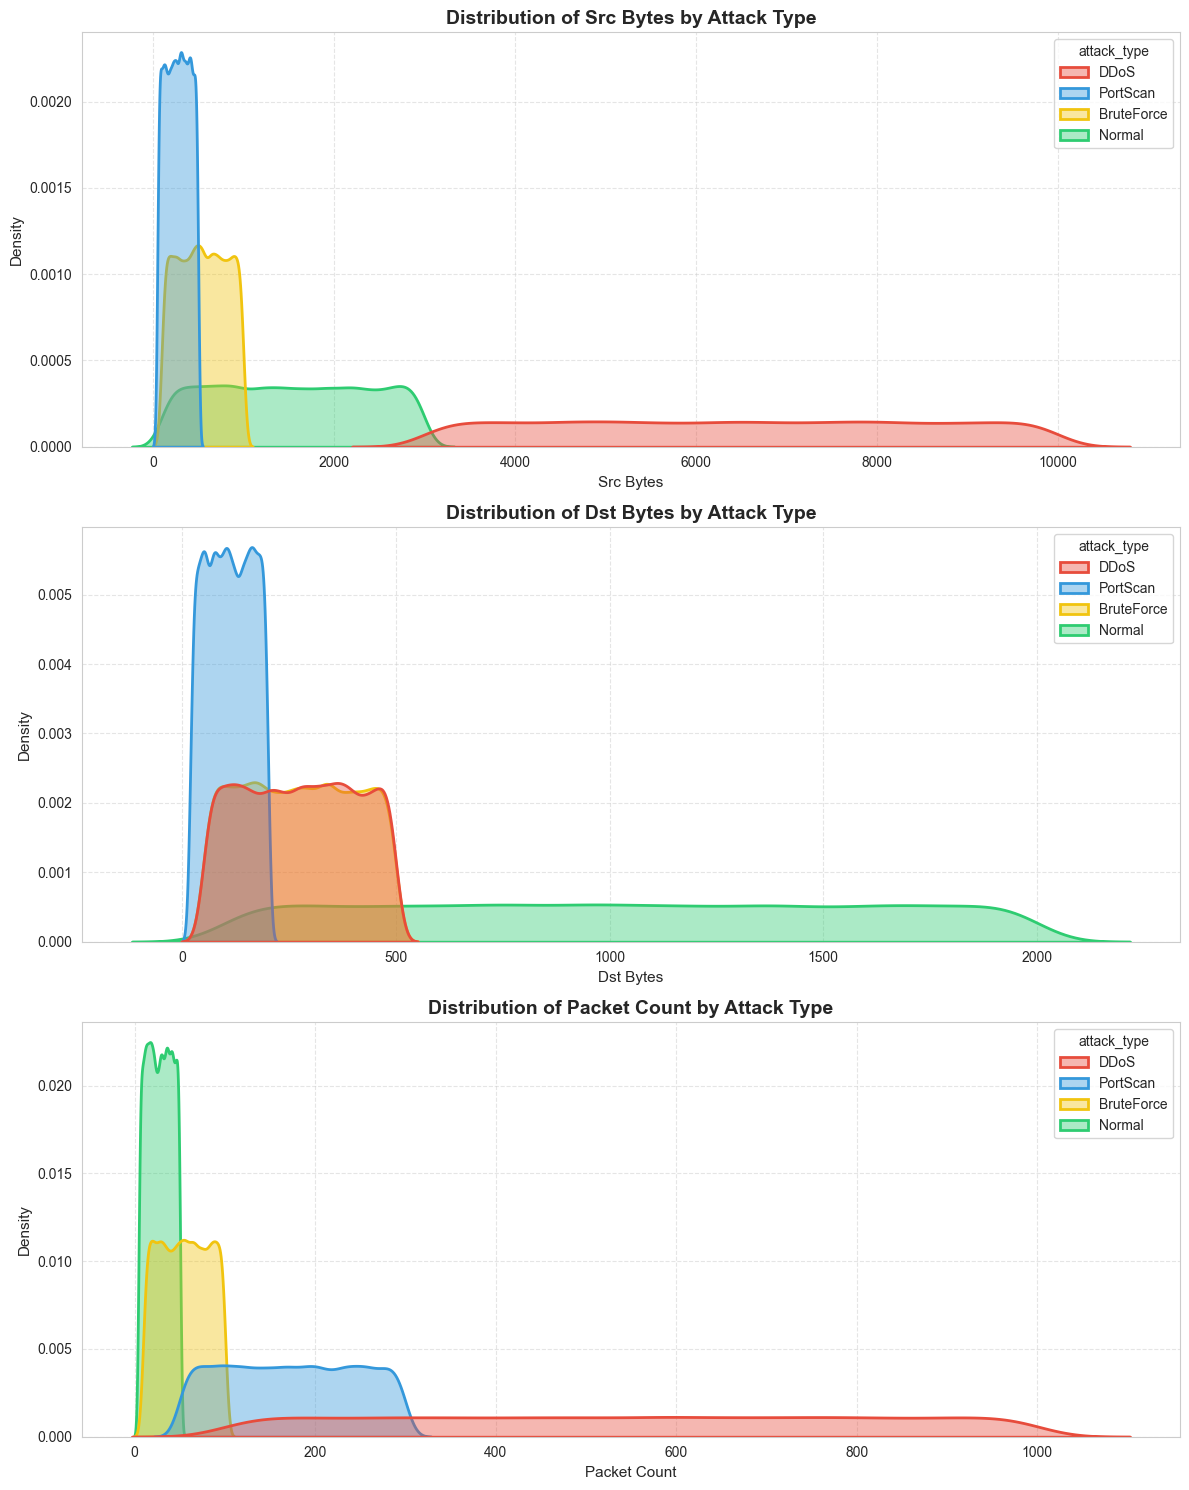

In [14]:
target_columns = [
    'src_bytes',
    'dst_bytes',
    'packet_count'
]

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 15)
)

axes = axes.flatten()

palette = {'Normal': '#2ecc71', 'DDoS': '#e74c3c', 'PortScan': '#3498db', 'BruteForce': '#f1c40f'}

for ax, col in zip(axes, target_columns):
    
    sns.kdeplot(
        data=df,
        x=col,
        hue='attack_type',
        fill=True,
        common_norm=False,
        palette=palette,
        alpha=0.4,
        linewidth=2,
        ax=ax
    )

    ax.set_title(
        f'Distribution of {col.replace("_", " ").title()} by Attack Type',
        fontsize=14,
        fontweight='bold'
    )
    ax.set_xlabel(col.replace("_", " ").title(), fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

os.makedirs('img', exist_ok=True)
filepath = os.path.join(
    'img',
    'Distribution_Analysis_by_Attack_Type.png'
)

plt.savefig(
    filepath,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()


## Chapter 3 : EDA

### 3.1 